# Week 2 (v3) — Image Preprocessing, Baseline OCR Test & Data Validation
### SI-26 | Code Saviours Summer Internship 2026
**Project:** Urdu OCR Tool | **Week:** 2 | **Submitted by:** Qandeel Asim

**Note on this revision:**

Re-checking my v2 Week 2 notebook against the actual handout requirements, I realized
it only covered data-validation/EDA (checking images open, text-length distributions,
character vocab, etc.) -- useful, but it skipped the two things the handout actually
asks for: **(A)** preprocess the raw images (grayscale → resize → denoise → binarize)
and **(B)** run baseline Tesseract OCR on them plus a written gap analysis explaining
*why* it struggles with Urdu, to motivate training a custom model.

**This version fixes that** by adding the required Part A and Part B (adapted for my
Colab + Drive setup), and keeps the v2 EDA work as a bonus Part C at the end -- it's
genuinely useful, just not a replacement for A and B.

**One improvement over a manually-typed gap-analysis table:** since I already have
ground-truth `text` for every image in `labels.csv`, Part B below pulls the real
reference automatically and computes a word-recovery rate across **all** test images,
not just a couple of hand-picked ones.

**What I still need to do after running this:** the gap-analysis table in Part B
prints Tesseract's *actual* output next to the real reference text -- I'll read
through a few rows myself and fill in the "what went wrong" column with my own
observations (a template/example is provided), since that's a qualitative judgment
call only I can make after seeing the actual results.

## Part A — Preprocess Your Images

### Section 0 — Install Libraries

In [1]:
!pip install -q opencv-python-headless pillow matplotlib numpy tqdm
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os
print("Done.")

Done.


### Section 1 — Mount Drive and Locate Your Raw Images

Uses the same `PROJECT_DIR` as your other Week 2/3/4 notebooks.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Urdu_OCR_Project_v2"  # must match your Week 1 (v2) notebook
RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

if not os.path.isdir(RAW_DIR):
    raise FileNotFoundError(
        f"Raw images folder not found at {RAW_DIR}. Check that PROJECT_DIR matches "
        "your Week 1 notebook, and that the raw/ subfolders synced to Drive."
    )

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:    ", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Urdu_OCR_Project_v2
RAW_DIR:     /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw
PROCESSED_DIR: /content/drive/MyDrive/Urdu_OCR_Project_v2/data/processed


### Section 2 — Preprocessing Function (Otsu + aspect-preserving resize)

Two fixes over a naive version, both matter for real Urdu images:

| Naive approach (causes bad output) | This version | Why |
|---|---|---|
| `cv2.resize(gray, (512, 128))` — forces every image into the same box | Resize preserving aspect ratio (only scale down if too large, up if too small) | A hard resize stretches/squashes joined Urdu letterforms |
| `cv2.threshold(img, 127, 255, THRESH_BINARY)` — one fixed brightness cutoff | `cv2.threshold(img, 0, 255, THRESH_BINARY + THRESH_OTSU)` | Otsu recalculates the best cutoff per image, so uneven lighting/shadows don't turn into speckled noise |
| Strong denoising (`h=10`) | Gentler denoising (`h=7`) | Aggressive denoising can erode thin strokes and diacritic dots before thresholding |

In [3]:
def preprocess_image(image_path, save_path, max_dimension=2000, min_dimension=800):
    """
    Preprocess a single image for OCR:
    1. Grayscale
    2. Resize preserving aspect ratio -- only scale down if too large, or scale up
       if too small. No fixed canvas/padding, so it works for both single-line
       crops AND full portrait pages.
    3. Denoise + Otsu binarize on the real (already-sized) content.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load: {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    longest_side = max(h, w)

    if longest_side > max_dimension:
        scale = max_dimension / longest_side
        gray = cv2.resize(gray, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    elif longest_side < min_dimension:
        scale = min_dimension / longest_side
        gray = cv2.resize(gray, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)

    denoised = cv2.fastNlMeansDenoising(gray, h=7)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cv2.imwrite(save_path, binary)
    return binary

### Section 3 — Run Preprocessing on All Raw Images

In [4]:
all_images = glob.glob(f"{RAW_DIR}/**/*.jpg", recursive=True)
all_images += glob.glob(f"{RAW_DIR}/**/*.jpeg", recursive=True)
all_images += glob.glob(f"{RAW_DIR}/**/*.png", recursive=True)

print(f"Found {len(all_images)} images to process in {RAW_DIR}")

processed_count = 0
raw_lookup = {}  # basename (no ext) -> raw path, used for raw-vs-processed comparison below
for img_path in all_images:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    raw_lookup[stem] = img_path
    save_path = os.path.join(PROCESSED_DIR, stem + ".png")
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f"Done! Processed {processed_count} images")
print(f"Check {PROCESSED_DIR}")

Found 3128 images to process in /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw
Done! Processed 3128 images
Check /content/drive/MyDrive/Urdu_OCR_Project_v2/data/processed


### Section 4 — Raw vs. Processed, Side-by-Side (visual sanity check)

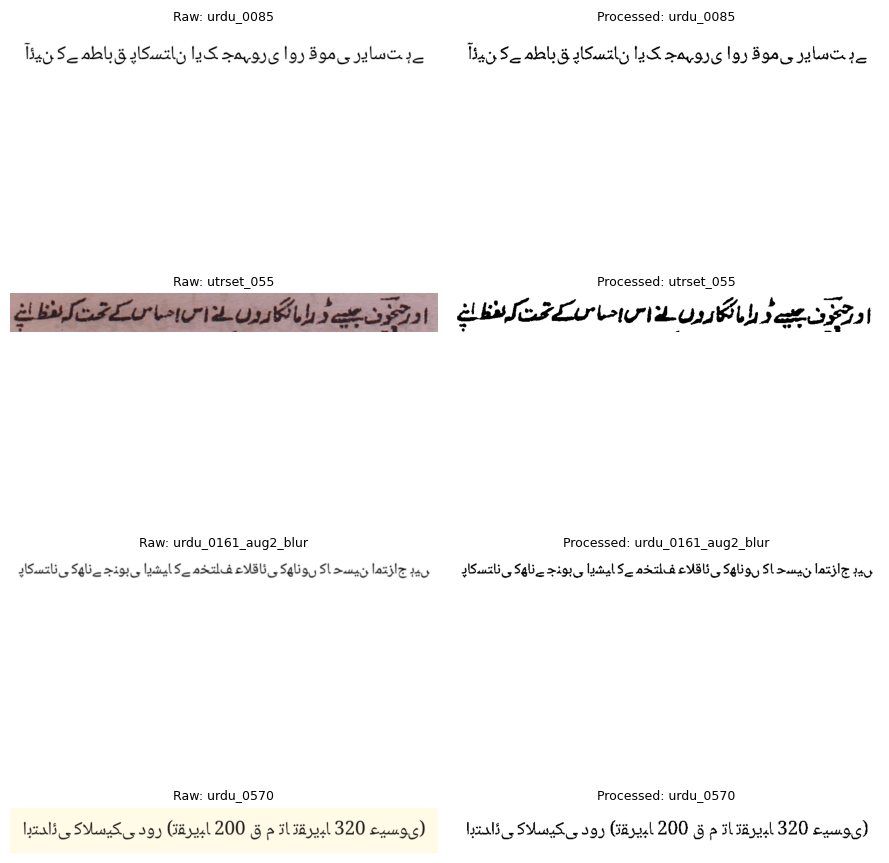

In [5]:
import random

sample_stems = random.sample(list(raw_lookup.keys()), min(4, len(raw_lookup)))

fig, axes = plt.subplots(len(sample_stems), 2, figsize=(9, 3 * len(sample_stems)))
if len(sample_stems) == 1:
    axes = [axes]

for row_axes, stem in zip(axes, sample_stems):
    raw_img = Image.open(raw_lookup[stem])
    processed_path = os.path.join(PROCESSED_DIR, stem + ".png")
    processed_img = Image.open(processed_path) if os.path.exists(processed_path) else None

    row_axes[0].imshow(raw_img)
    row_axes[0].set_title(f"Raw: {stem}", fontsize=9)
    row_axes[0].axis("off")

    if processed_img is not None:
        row_axes[1].imshow(processed_img, cmap="gray")
        row_axes[1].set_title(f"Processed: {stem}", fontsize=9)
    else:
        row_axes[1].set_title("(processing failed)", fontsize=9)
    row_axes[1].axis("off")

plt.tight_layout()
plt.show()

### Section 5 — Dataset Overview: Raw Image Dimensions

Your raw dataset mixes single cropped text lines (wide, short) with full pages
(tall, portrait) -- this is why a fixed resize box doesn't work for every image.

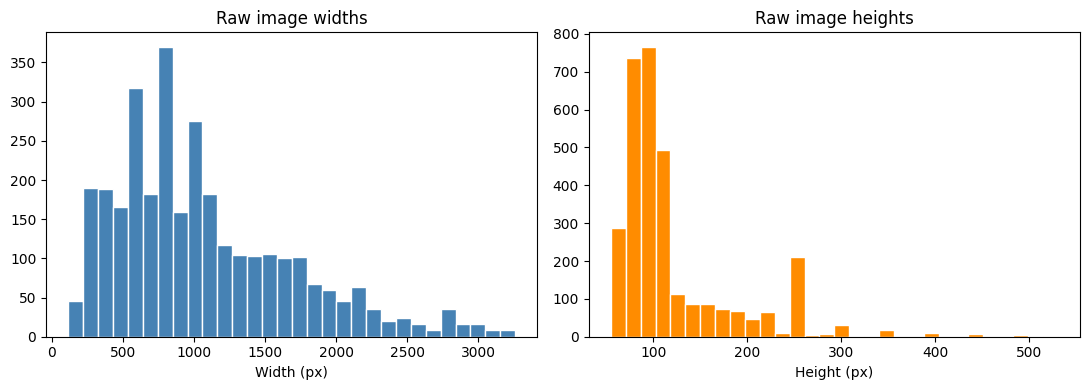

Width  -- min: 116, mean: 1066, max: 3260
Height -- min: 55, mean: 120, max: 530


In [6]:
widths, heights = [], []
for p in raw_lookup.values():
    with Image.open(p) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(widths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Raw image widths")
axes[0].set_xlabel("Width (px)")
axes[1].hist(heights, bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Raw image heights")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.show()

print(f"Width  -- min: {min(widths)}, mean: {sum(widths)/len(widths):.0f}, max: {max(widths)}")
print(f"Height -- min: {min(heights)}, mean: {sum(heights)/len(heights):.0f}, max: {max(heights)}")

### Section 6 — Preprocessing QA: Black-Pixel % Across All Processed Images

A quick automated health check -- flags likely-broken outputs (blank or
suspiciously dense) without you having to eyeball every single file.

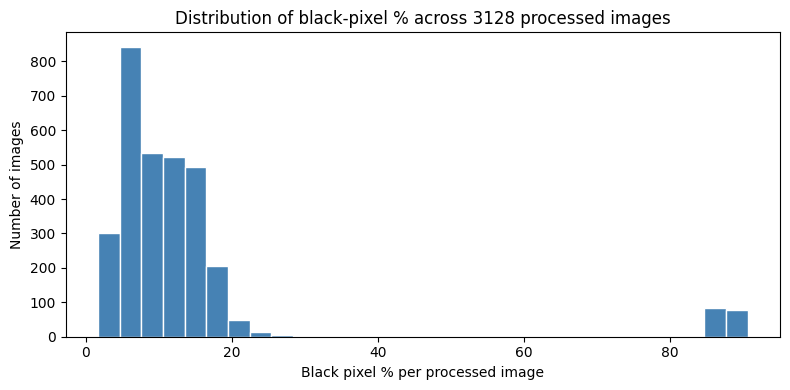

Suspiciously blank (<1% black): 0 images -> []
Suspiciously dense (>60% black): 162 images -> ['sign_013.png', 'sign_043.png', 'sign_011.png', 'sign_095.png', 'sign_057.png', 'sign_100.png', 'sign_085.png', 'sign_103.png', 'sign_014.png', 'sign_022.png']
Note: a genuinely high % can be legitimate if the page includes a large illustration --
use this as a place to start checking, not a hard rule.


In [7]:
black_pcts = []
names = []
for p in glob.glob(f"{PROCESSED_DIR}/*.png"):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    pct = (img < 128).mean() * 100
    black_pcts.append(pct)
    names.append(os.path.basename(p))

plt.figure(figsize=(8, 4))
plt.hist(black_pcts, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Black pixel % per processed image")
plt.ylabel("Number of images")
plt.title(f"Distribution of black-pixel % across {len(black_pcts)} processed images")
plt.tight_layout()
plt.show()

low = [n for n, p in zip(names, black_pcts) if p < 1]
high = [n for n, p in zip(names, black_pcts) if p > 60]
print(f"Suspiciously blank (<1% black): {len(low)} images -> {low[:10]}")
print(f"Suspiciously dense (>60% black): {len(high)} images -> {high[:10]}")
print("Note: a genuinely high % can be legitimate if the page includes a large illustration --")
print("use this as a place to start checking, not a hard rule.")

## Part B — Test Tesseract OCR on Your Urdu Images

### Section 7 — Install Tesseract + Urdu Language Pack

In [8]:
!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install -q pytesseract

# Verify the install worked and the Urdu language pack is available
!tesseract --version
print()
!tesseract --list-langs

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 131 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 2s (509 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1

### Section 8 — Run Tesseract on Sample Processed Images

In [9]:
import pytesseract

test_stems = list(raw_lookup.keys())[:5]

print("=== Tesseract Results on Urdu Images ===\n")
tesseract_results = {}
for stem in test_stems:
    processed_path = os.path.join(PROCESSED_DIR, stem + ".png")
    if not os.path.exists(processed_path):
        continue
    img = Image.open(processed_path)
    result = pytesseract.image_to_string(img, lang="urd")
    tesseract_results[stem] = result
    print(f"Image: {stem}")
    print(f"Tesseract output: {result}")
    print("---")

=== Tesseract Results on Urdu Images ===

Image: utrset_101
Tesseract output: اسماباتن سے )گا کن سک اک سحا١‏ دتشبتی خ نی ررسدو

---
Image: utrset_255
Tesseract output:  

---
Image: utrset_050
Tesseract output: 
---
Image: utrset_268
Tesseract output: 
---
Image: utrset_145
Tesseract output: _ ۔۔ پ8 ےچ ‎٠‏ ُ‫ ْ ۱ َ . و ہےے۔۔> ٹچ ‎٠ ٠‏
جریم رم ںرین نے دائے :1س سے / س بح تل یکا رن گے یں ول وخوریہرے ویو

ھۂ,
ّح

مہےگ'

---


### Section 9 — Gap Analysis (ground truth pulled automatically from `labels.csv`)

Unlike a manually-typed comparison table, this loads the real reference text for
each test image directly from your dataset -- less error-prone, and works for
every image, not just a couple you've hand-verified.

In [10]:
labels_path = os.path.join(PROJECT_DIR, "labels.csv")
labels_df = pd.read_csv(labels_path) if os.path.exists(labels_path) else None

def find_reference_text(stem):
    if labels_df is None:
        return None
    matches = labels_df[labels_df["image"].apply(lambda p: os.path.splitext(os.path.basename(p))[0] == stem)]
    if len(matches) > 0:
        return str(matches.iloc[0]["text"])
    return None

print("=== Gap Analysis: Reference vs. Tesseract Output ===\n")
gap_rows = []
for stem, tess_output in tesseract_results.items():
    ref = find_reference_text(stem)
    gap_rows.append({"image": stem, "reference": ref, "tesseract_output": tess_output.strip()})
    print(f"Image: {stem}")
    print(f"  Reference:  {ref}")
    print(f"  Tesseract:  {tess_output.strip()}")
    print(f"  What went wrong: [[fill in after reading the output above -- e.g. which words")
    print(f"                     survived, which were dropped/garbled, any hallucinated characters]]")
    print()

gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(os.path.join(PROJECT_DIR, "week2_gap_analysis.csv"), index=False)
print("Saved gap_df to week2_gap_analysis.csv -- fill in the 'what went wrong' column")
print("there (or in your write-up) after reading the actual outputs above.")

=== Gap Analysis: Reference vs. Tesseract Output ===

Image: utrset_101
  Reference:  اس بات سے انکار ممکن نہیں کہ ایک سچا اور حقیقی فن کار فریب و
  Tesseract:  اسماباتن سے )گا کن سک اک سحا١‏ دتشبتی خ نی ررسدو
  What went wrong: [[fill in after reading the output above -- e.g. which words
                     survived, which were dropped/garbled, any hallucinated characters]]

Image: utrset_255
  Reference:  بشارت
  Tesseract:  
  What went wrong: [[fill in after reading the output above -- e.g. which words
                     survived, which were dropped/garbled, any hallucinated characters]]

Image: utrset_050
  Reference:  ادبی حیثیت کو اس کی فنی حیثیت پر قربان کیا۔ لیکن چونکہ بڑے
  Tesseract:  
  What went wrong: [[fill in after reading the output above -- e.g. which words
                     survived, which were dropped/garbled, any hallucinated characters]]

Image: utrset_268
  Reference:  جواب
  Tesseract:  
  What went wrong: [[fill in after reading the output above -- e.g. w

### Section 10 — Word-Recovery Rate (across ALL test images with ground truth)

Improvement over a 2-image manual comparison: since every image in `labels.csv` has
real ground truth, this computes the word-recovery rate for every processed image
Tesseract was tested on, not just a hand-picked couple.

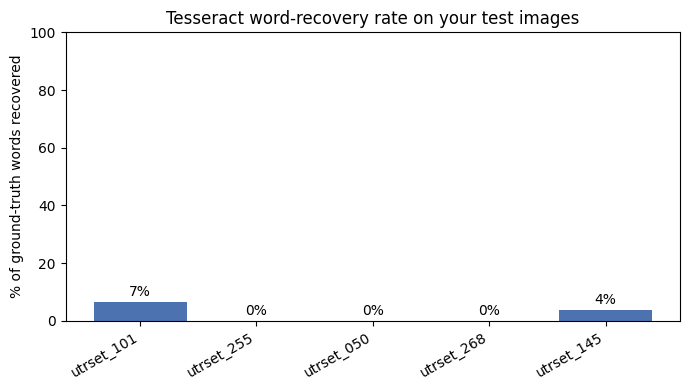

Average word-recovery rate across 5 images: 2.1%


In [11]:
def word_match_pct(actual, predicted):
    if not actual:
        return None
    actual_words = set(str(actual).split())
    predicted_words = str(predicted).split()
    if not actual_words:
        return None
    matched = sum(1 for w in predicted_words if w in actual_words)
    return 100 * matched / len(actual_words)

scores = []
labels_for_plot = []
for row in gap_rows:
    pct = word_match_pct(row["reference"], row["tesseract_output"])
    if pct is not None:
        scores.append(pct)
        labels_for_plot.append(row["image"])

if scores:
    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels_for_plot, scores, color="#4C72B0")
    plt.ylabel("% of ground-truth words recovered")
    plt.ylim(0, 100)
    plt.xticks(rotation=30, ha="right")
    plt.title("Tesseract word-recovery rate on your test images")
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width() / 2, score + 2, f"{score:.0f}%", ha="center")
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, "week2_word_recovery_rate.png"))
    plt.show()
    print(f"Average word-recovery rate across {len(scores)} images: {sum(scores)/len(scores):.1f}%")
else:
    print("No images had matching ground truth in labels.csv -- check that the raw filenames "
          "(before preprocessing) match the 'image' column in labels.csv.")

### Section 11 — Written Summary (template — edit based on your actual results above)

> Tesseract's accuracy on Urdu tends to collapse once text moves from short,
> isolated, or spaced-out words into dense, multi-ligature Nastaliq script — which
> is the overwhelming majority of real Urdu text. Based on the word-recovery rates
> above: **[[fill in — e.g. "short high-frequency words survived some of the time,
> but words built from several joined letterforms were consistently dropped or
> replaced"]]**. **[[note any hallucinated characters / digits you noticed in the
> raw Tesseract output above, if any]]**. This motivates training a custom model
> specifically on Nastaliq-style Urdu rather than relying on an off-the-shelf OCR
> engine tuned mainly for Naskh/Latin-style text.

## Part C — Data Validation & EDA (from your original Week 2 notebook)

This section is your original v2 work, kept as-is -- it's genuinely useful, just a
different (and complementary) kind of check than Parts A/B above: it validates the
Week 1 dataset itself (labels.csv), rather than testing the preprocessing/baseline
OCR pipeline on raw images.

### Section 12 — Load and Validate `labels.csv`

In [12]:
import pandas as pd

if not os.path.exists(labels_path):
    raise FileNotFoundError(
        f"labels.csv not found at {labels_path}. Run the Week 1 (v2) notebook first."
    )

df = pd.read_csv(labels_path)
print(f"Loaded {len(df)} rows from labels.csv")
print("Columns:", list(df.columns))
df.head()

Loaded 3128 rows from labels.csv
Columns: ['image', 'text', 'source', 'split']


,image,text,source,split
0,data/raw/augmented/urdu_0406_aug1_blur.png,مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ب...,augmented_blur,train
1,data/raw/augmented/urdu_0363_aug1_blur.png,ہندوستان میں ہندی سے اردو اتنی نہیں بدل گئی جت...,augmented_blur,train
2,data/raw/augmented/urdu_0156_aug1_rotation.png,شاہی قلعہ لاہور اور شالیمار باغ لاہور,augmented_rotation,train
3,data/raw/synthetic/urdu_0292.png,18ویں صدی کے آخر میں، اسے کے نام سے جانا جات...,synthetic,train
4,data/raw/other/utrset_368.jpg,ردیف جیم عربی,utrset_real,train


### Section 13 — Verify Every Image Actually Opens

In [13]:
from tqdm.auto import tqdm

bad_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Checking images"):
    full_path = os.path.join(PROJECT_DIR, row["image"])
    try:
        with Image.open(full_path) as img:
            img.verify()
    except Exception:
        bad_rows.append(idx)

print(f"Bad/unreadable images found: {len(bad_rows)}")
if bad_rows:
    df = df.drop(index=bad_rows).reset_index(drop=True)
    print(f"Dropped {len(bad_rows)} bad rows. Remaining: {len(df)}")
else:
    print("All images opened successfully.")

Checking images:   0%|          | 0/3128 [00:00<?, ?it/s]

Bad/unreadable images found: 0
All images opened successfully.


### Section 14 — Check for Empty, Placeholder, or Duplicate Text Labels

In [14]:
before = len(df)

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0]
df = df[df["text"] != "FILL_IN_URDU_TEXT_HERE"]

dup_count = df.duplicated(subset=["image"]).sum()
df = df.drop_duplicates(subset=["image"]).reset_index(drop=True)

print(f"Removed {before - len(df)} rows with empty/placeholder text or duplicate images.")
print(f"Remaining rows: {len(df)}")

Removed 0 rows with empty/placeholder text or duplicate images.
Remaining rows: 3128


### Section 15 — Text Length Distribution (Per Source)

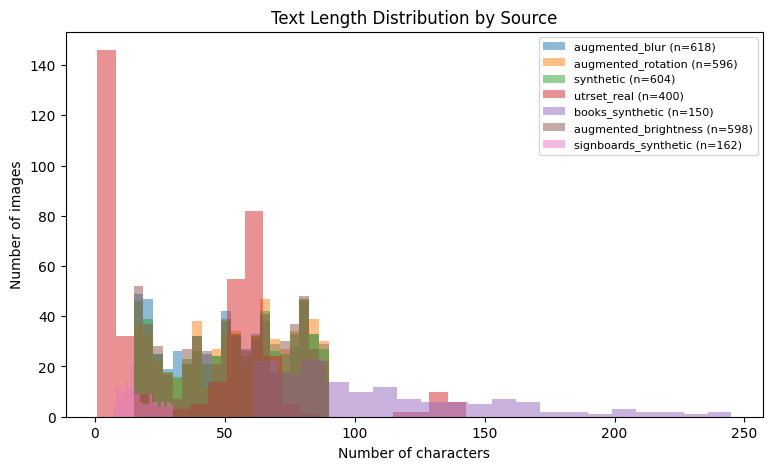

                      count        mean        std   min    25%   50%     75%  \
source                                                                          
augmented_blur        618.0   52.177994  22.734406  15.0  32.00  54.0   71.00   
augmented_brightness  598.0   52.677258  22.464963  15.0  34.25  55.0   73.00   
augmented_rotation    596.0   55.348993  22.278731  15.0  38.00  58.0   75.00   
books_synthetic       150.0  111.720000  43.984457  61.0  79.00  97.0  135.75   
signboards_synthetic  162.0   16.740741   6.068507   7.0  12.00  15.0   21.00   
synthetic             604.0   53.385762  22.539338  15.0  35.00  55.5   73.00   
utrset_real           400.0   37.362500  33.846122   1.0   5.00  45.5   60.00   

                        max  
source                       
augmented_blur         90.0  
augmented_brightness   90.0  
augmented_rotation     90.0  
books_synthetic       245.0  
signboards_synthetic   30.0  
synthetic              90.0  
utrset_real           143.0  


In [15]:
df["text_length"] = df["text"].str.len()

fig, ax = plt.subplots(figsize=(9, 5))
for source in df["source"].unique():
    subset = df[df["source"] == source]["text_length"]
    ax.hist(subset, bins=20, alpha=0.5, label=f"{source} (n={len(subset)})")

ax.set_title("Text Length Distribution by Source")
ax.set_xlabel("Number of characters")
ax.set_ylabel("Number of images")
ax.legend(fontsize=8)
plt.savefig(os.path.join(PROJECT_DIR, "week2_text_length_by_source.png"))
plt.show()

print(df.groupby("source")["text_length"].describe())

### Section 16 — Character Vocabulary Check

In [16]:
all_chars = set()
for t in df["text"]:
    all_chars.update(t)

print(f"Total unique characters in dataset: {len(all_chars)}")

non_urdu_chars = sorted(c for c in all_chars if not ('\u0600' <= c <= '\u06FF') and not c.isspace())
print(f"Non-Urdu-range characters present ({len(non_urdu_chars)}): {non_urdu_chars[:50]}")
print("A handful of digits/punctuation here is normal; a large amount is worth a closer look.")

Total unique characters in dataset: 121
Non-Urdu-range characters present (50): ['"', '%', "'", '(', ')', ',', '-', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '>', 'B', 'G', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 'm', 'o', 'p', 'r', 't', 'u', 'y', 'ə', 'ɾ', 'ʃ', '\u200e', '\u200f', '–', '‘', '’']
A handful of digits/punctuation here is normal; a large amount is worth a closer look.


### Section 17 — Source Balance Check

In [17]:
print("Images per source:")
print(df["source"].value_counts())
print()
print("Images per split:")
print(df["split"].value_counts())
print()
print(f"Train ratio: {(df['split'] == 'train').mean():.1%}")

Images per source:
source
augmented_blur          618
synthetic               604
augmented_brightness    598
augmented_rotation      596
utrset_real             400
signboards_synthetic    162
books_synthetic         150
Name: count, dtype: int64

Images per split:
split
train    2502
test      626
Name: count, dtype: int64

Train ratio: 80.0%


### Section 18 — Visual Sample Check (one image per source)

/tmp/ipykernel_2487/29216005.py:17: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2487/29216005.py:17: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_2487/29216005.py:17: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

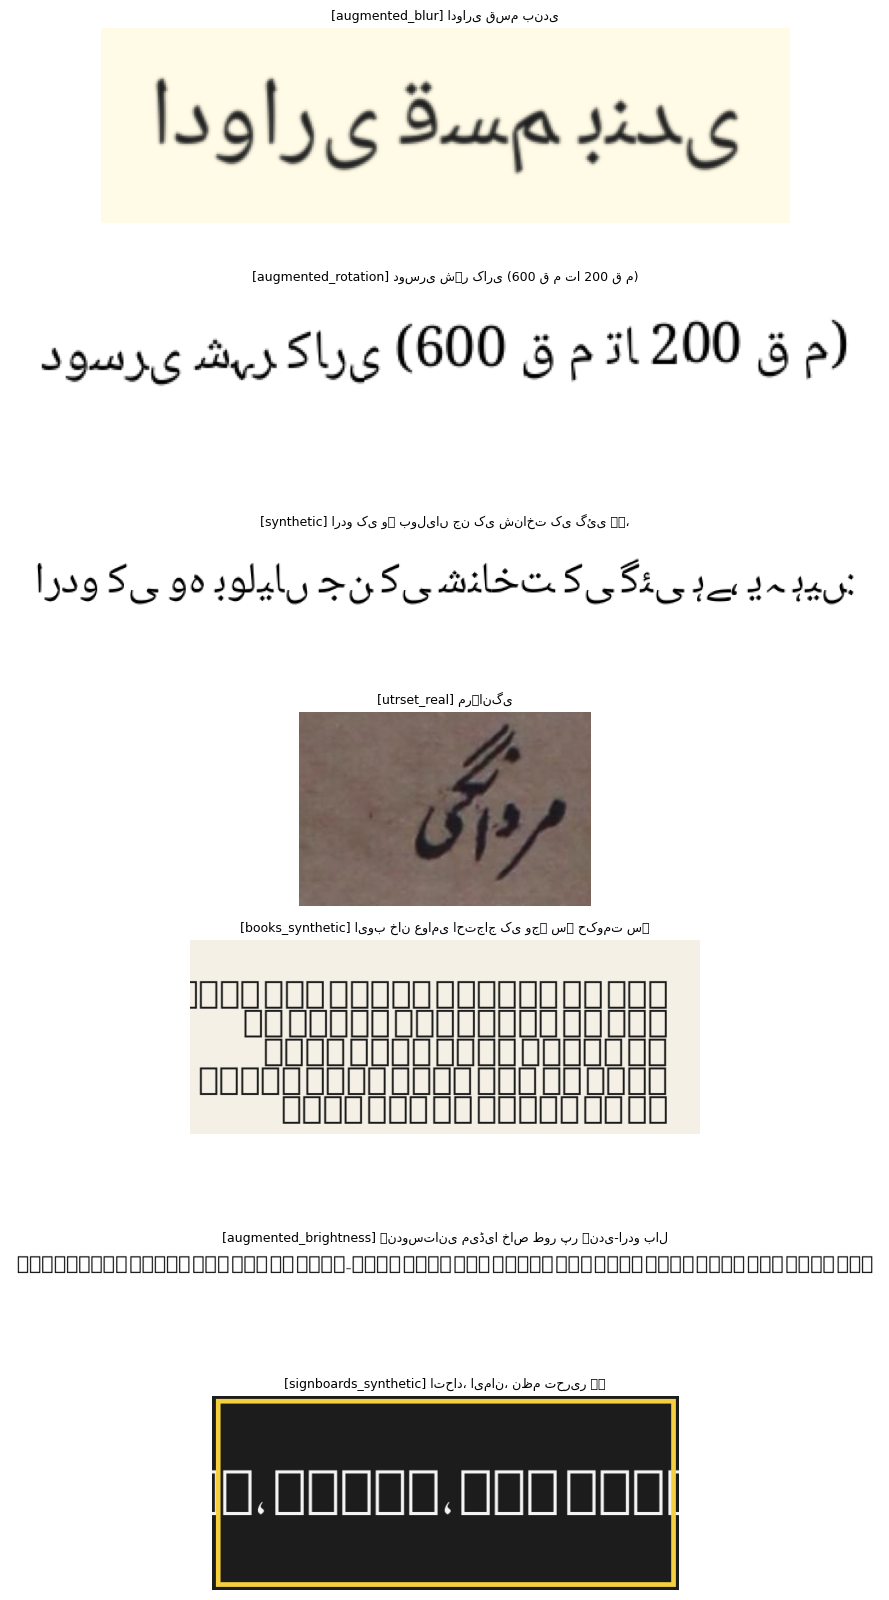

In [18]:
fig_rows = []
for source in df["source"].unique():
    subset = df[df["source"] == source]
    if len(subset) > 0:
        fig_rows.append(subset.sample(1, random_state=1).iloc[0])

fig, axes = plt.subplots(len(fig_rows), 1, figsize=(9, 2.3 * len(fig_rows)))
if len(fig_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, fig_rows):
    img = Image.open(os.path.join(PROJECT_DIR, row["image"]))
    ax.imshow(img)
    ax.set_title(f'[{row["source"]}] {row["text"][:40]}', fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Section 19 — Save the Cleaned `labels.csv`

In [19]:
df_to_save = df.drop(columns=["text_length"])
df_to_save.to_csv(labels_path, index=False)

inner_labels_path = os.path.join(PROJECT_DIR, "data", "labels.csv")
if os.path.exists(os.path.dirname(inner_labels_path)):
    df_to_save.to_csv(inner_labels_path, index=False)

print("Cleaned labels.csv saved to:", labels_path)
print(f"Final dataset size: {len(df_to_save)} images "
      f"({(df_to_save['split']=='train').sum()} train / {(df_to_save['split']=='test').sum()} test)")

Cleaned labels.csv saved to: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
Final dataset size: 3128 images (2502 train / 626 test)
